In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
#Load the MNIST dataset
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.mnist.load_data()
print("Training images:",x_train.shape)
print("Testing images:",x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


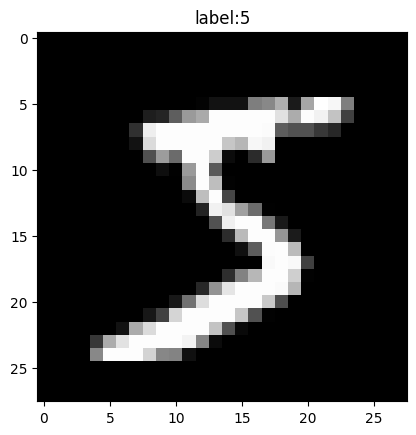

In [ ]:
#Look at sample images
import matplotlib.pyplot as plt
plt.imshow(x_train[0], cmap='gray')
plt.title(f'label:{y_train[0]}')
plt.show()

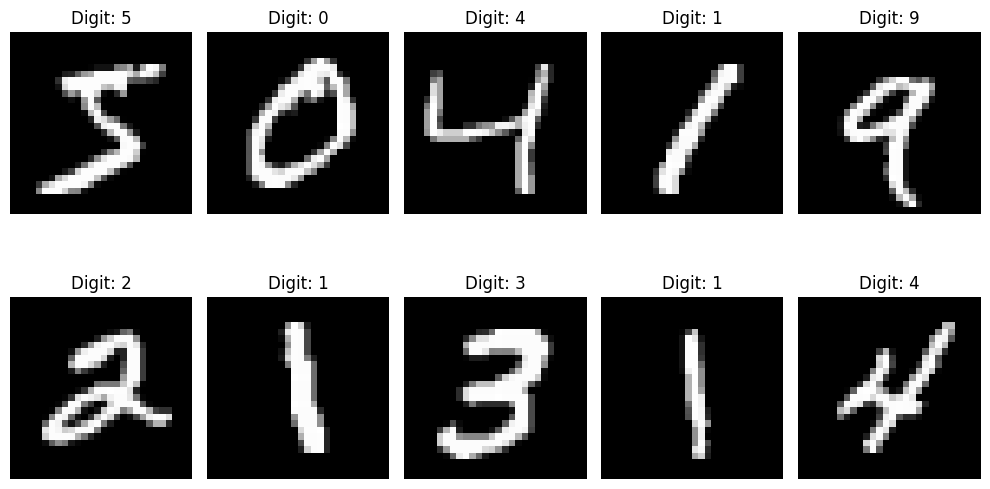

In [ ]:
plt.figure(figsize=(10, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(
        x_train[i],
        cmap="gray"
    )
    plt.title(
        f"Digit: {y_train[i]}"
    )
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
X = x_train.reshape(
    x_train.shape[0],
    784
)

X_test = x_test.reshape(
    x_test.shape[0],
    784
)

print("X:", X.shape)
print("X_test:", X_test.shape)

X: (60000, 784)
X_test: (10000, 784)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_train,
    test_size=0.10,
    random_state=42,
    stratify=y_train
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (54000, 784)
X_val: (6000, 784)
X_test: (10000, 784)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(54000, 784)
(6000, 784)
(10000, 784)


In [ ]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(
    y_train,
    num_classes=10
)

y_val = to_categorical(
    y_val,
    num_classes=10
)

y_test = to_categorical(
    y_test,
    num_classes=10
)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

y_train: (54000, 10)
y_val: (6000, 10)
y_test: (10000, 10)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(
    Dense(
        128,
        activation="relu",
        input_shape=(784,)
    )
)

model.add(
    Dense(
        64,
        activation="relu"
    )
)

model.add(
    Dense(
        10,
        activation="softmax"
    )
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=128,
    validation_data=(X_val, y_val)
)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9139 - loss: 0.2942 - val_accuracy: 0.9507 - val_loss: 0.1785
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9684 - loss: 0.1081 - val_accuracy: 0.9642 - val_loss: 0.1417
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9797 - loss: 0.0677 - val_accuracy: 0.9662 - val_loss: 0.1366
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9852 - loss: 0.0475 - val_accuracy: 0.9728 - val_loss: 0.1321
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9895 - loss: 0.0351 - val_accuracy: 0.9683 - val_loss: 0.1507
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9914 - loss: 0.0286 - val_accuracy: 0.9678 - val_loss: 0.1594
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9934 - loss: 0.0217 - val_accuracy: 0.9667 - val_loss: 0.1662
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9945 - loss: 0.0188 - val_accuracy: 0

In [ ]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)
print("Test Accuracy (%):", accuracy * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9733 - loss: 0.2616
Test Loss: 0.2616328001022339
Test Accuracy: 0.9732999801635742
Test Accuracy (%): 97.32999801635742


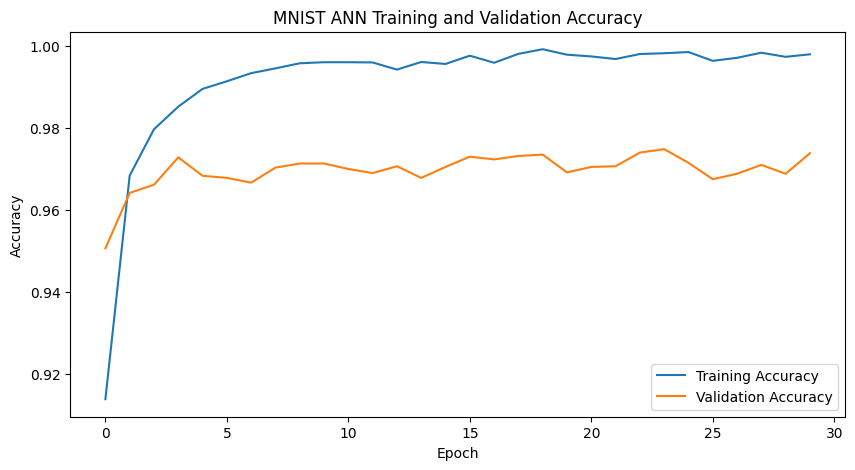

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "MNIST ANN Training and Validation Accuracy"
)

plt.legend()
plt.show()

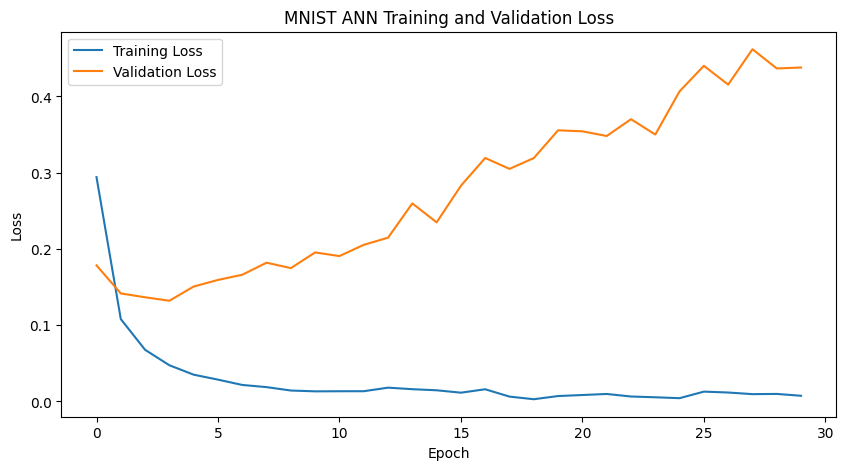

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "MNIST ANN Training and Validation Loss"
)

plt.legend()
plt.show()

In [ ]:
import numpy as np
y_pred_prob = model.predict(X_test)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

y_actual = np.argmax(
    y_test,
    axis=1
)

print("Predicted:", y_pred[:10])
print("Actual:   ", y_actual[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted: [7 2 1 0 4 1 4 9 5 9]
Actual:    [7 2 1 0 4 1 4 9 5 9]


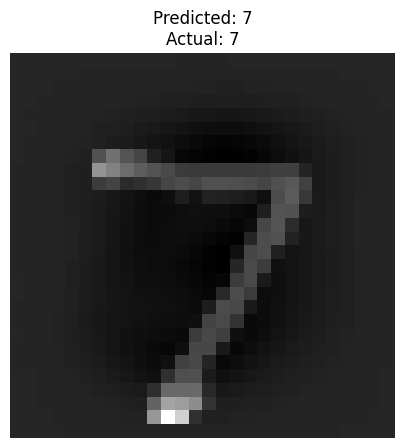

In [ ]:
index = 0

plt.figure(figsize=(5, 5))

plt.imshow(
    X_test[index].reshape(28, 28),
    cmap="gray"
)

plt.title(
    f"Predicted: {y_pred[index]}\n"
    f"Actual: {y_actual[index]}"
)

plt.axis("off")
plt.show()

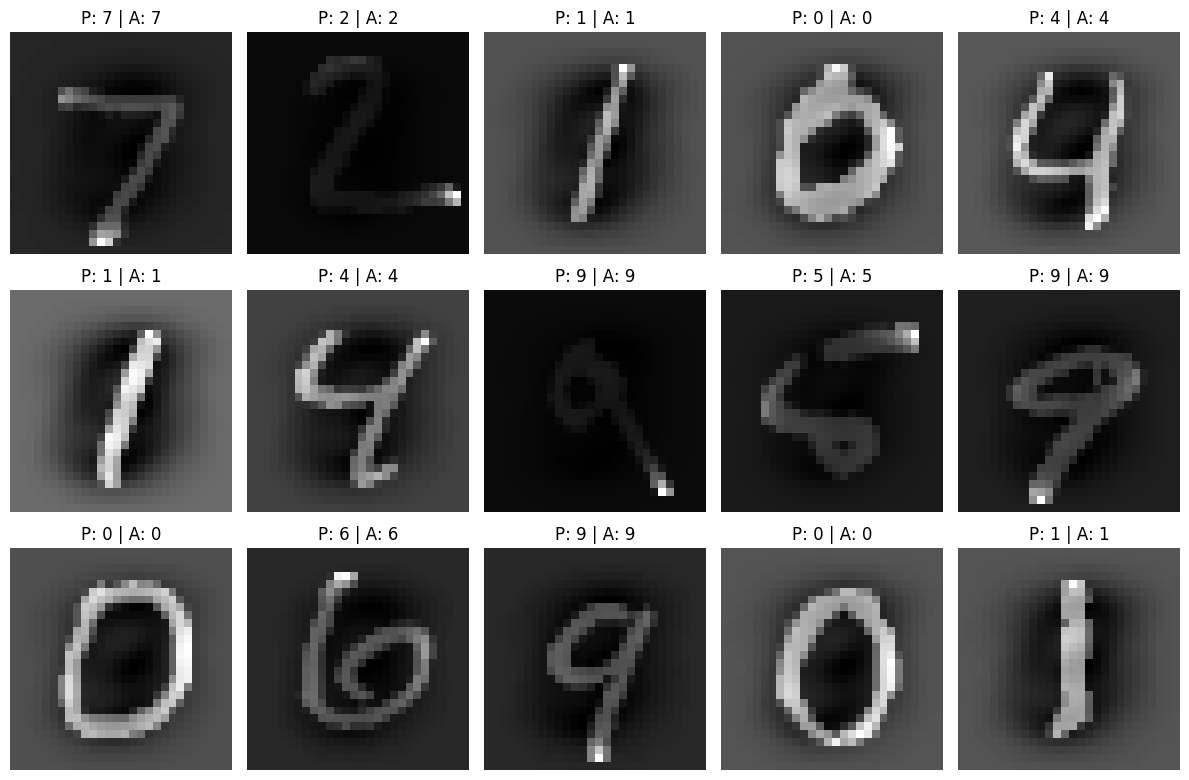

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(15):

    plt.subplot(3, 5, i + 1)

    plt.imshow(
        X_test[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        f"P: {y_pred[i]} | A: {y_actual[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

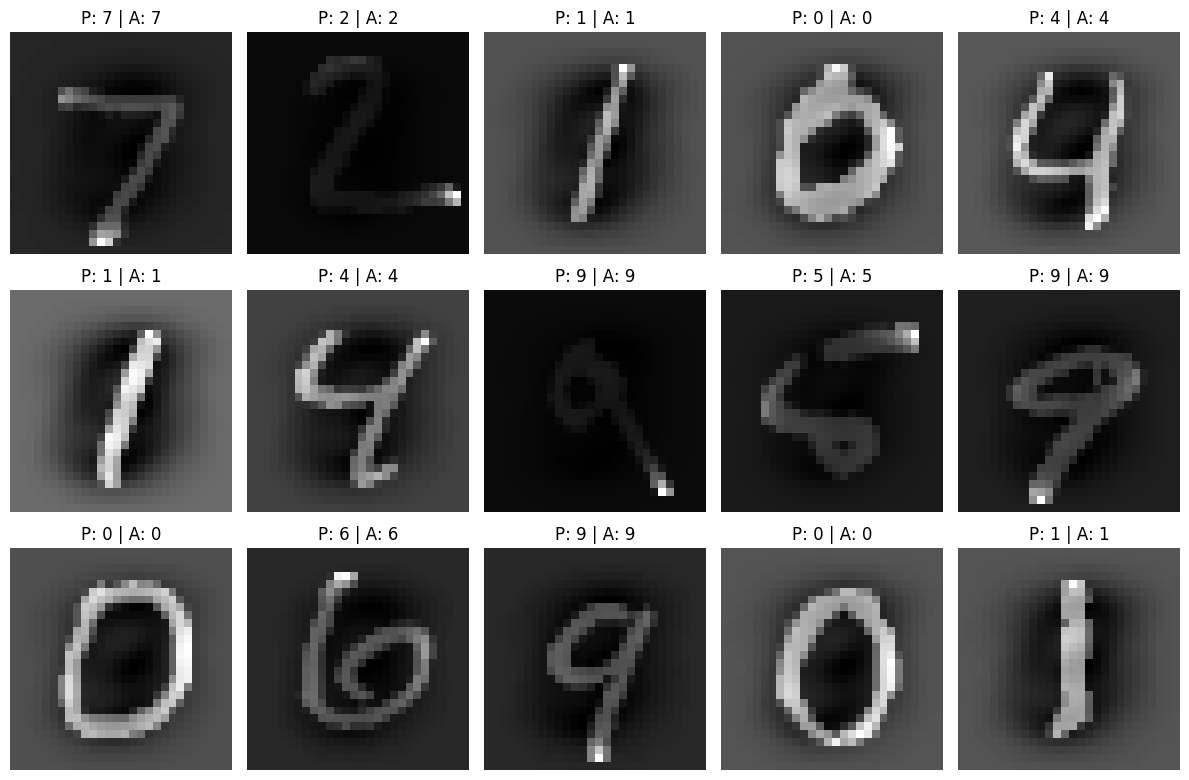

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(15):

    plt.subplot(3, 5, i + 1)

    plt.imshow(
        X_test[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        f"P: {y_pred[i]} | A: {y_actual[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

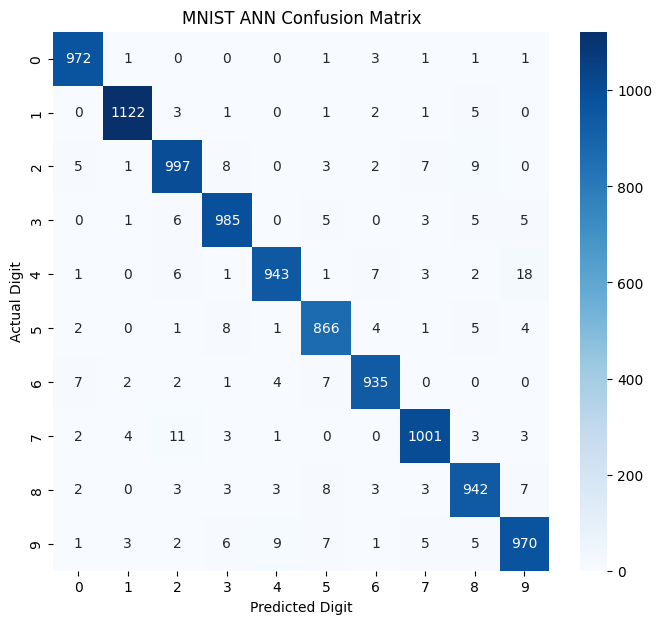

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_actual,
    y_pred
)

plt.figure(figsize=(8, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")

plt.title(
    "MNIST ANN Confusion Matrix"
)

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_actual,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.97      0.98      0.97      1010
           4       0.98      0.96      0.97       982
           5       0.96      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.96      0.97      0.97       974
           9       0.96      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9733 - loss: 0.2616
Test Loss: 0.2616328001022339
Test Accuracy: 0.9732999801635742


In [ ]:
model.save(
    "/content/mnist_ann.keras"
)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
from IPython.display import FileLink

model_path = "/kaggle/working/mnist_ann.keras"

print("Model saved successfully!")
FileLink(model_path)

Model saved successfully!


/kaggle/working/mnist_ann.keras

In [ ]:
# Save the trained ANN model
model.save("/content/mnist_ann.keras")

print("Model saved successfully!")

# Create download link
from IPython.display import FileLink

FileLink("/content/mnist_ann.keras")

Model saved successfully!


/content/mnist_ann.keras